# Лабораторная работа №1: Первичное исследование и оценка качества данных

## 1. Постановка задачи

Данные представляют собой список транзакций интернет-магазина электроники за период с января 2024 по май 2025 года. Датасет содержит информацию о продажах товаров: наушники, ноутбуки, телефоны, зарядки, чехлы. Покупатели из 5 городов России: Москва, Санкт-Петербург, Екатеринбург, Новосибирск, Казань.

**Условный заказчик:** отдел аналитики интернет-магазина электроники.

**Возможные задачи ИАД:**
- прогнозирование выручки по дням/месяцам;
- кластеризация покупателей по возрасту и способу оплаты;
- анализ сезонности продаж по городам.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_excel('ПРОДАЖА_data_(1).xlsx')
print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Размер: 502 строк, 9 столбцов


,id,дата,товар,город,количество,цена,скидка_%,возраст,оплата
0,1,2024-01-01,Наушники,Новосибирск,1,13476,15.0,30.0,онлайн
1,2,2024-01-02,Зарядка,Казань,3,3372,10.0,35.0,карта
2,3,2024-01-03,Наушники,СПб,3,4824,15.0,35.0,наличные
3,4,2024-01-04,Ноутбук,Екатеринбург,3,80294,15.0,50.0,карта
4,5,2024-01-05,Чехол,СПб,4,1858,15.0,30.0,наличные


## 2. Паспорт датасета

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          502 non-null    int64         
 1   дата        502 non-null    datetime64[ns]
 2   товар       502 non-null    object        
 3   город       502 non-null    object        
 4   количество  502 non-null    int64         
 5   цена        502 non-null    int64         
 6   скидка_%    491 non-null    float64       
 7   возраст     491 non-null    float64       
 8   оплата      502 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 35.4+ KB


In [64]:
df.describe()

,id,дата,количество,цена,скидка_%,возраст
count,502.000000,502,502.000000,502.000000,491.000000,491.000000
mean,249.507968,2024-09-05 12:11:28.446215168,2.679283,27410.768924,7.270876,34.993890
min,1.000000,2024-01-01 00:00:00,1.000000,507.000000,0.000000,18.000000
25%,124.250000,2024-05-03 06:00:00,1.000000,1949.500000,0.000000,25.000000
50%,249.500000,2024-09-05 12:00:00,2.000000,8850.500000,5.000000,35.000000
75%,374.750000,2025-01-08 18:00:00,3.000000,57463.000000,10.000000,45.000000
max,500.000000,2025-05-14 00:00:00,100.000000,99971.000000,15.000000,150.000000
std,145.045478,NaN,4.495144,31814.257714,5.577464,11.659364


In [65]:
passport = pd.DataFrame({
    'Столбец': df.columns,
    'Тип': df.dtypes.values,
    'Уникальных': [df[col].nunique() for col in df.columns],
    'Пропуски': df.isnull().sum().values,
    '% пропусков': (df.isnull().sum() / len(df) * 100).round(2).values
})
passport

,Столбец,Тип,Уникальных,Пропуски,% пропусков
0,id,int64,500,0,0.00
1,дата,datetime64[ns],500,0,0.00
2,товар,object,5,0,0.00
3,город,object,5,0,0.00
4,количество,int64,5,0,0.00
5,цена,int64,497,0,0.00
6,скидка_%,float64,4,11,2.19
7,возраст,float64,8,11,2.19
8,оплата,object,3,0,0.00


## 3. Аудит качества данных

### 3.1. Пропуски

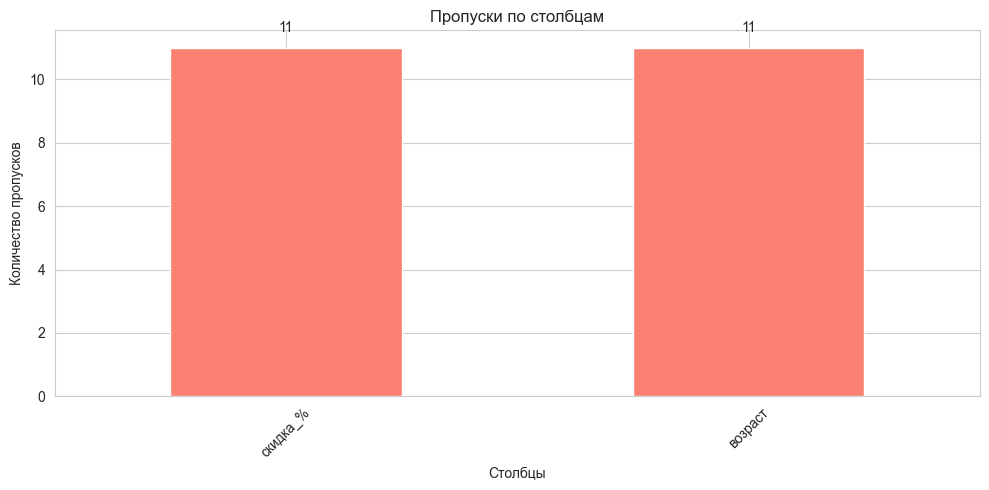

In [66]:
plt.figure(figsize=(10, 5))
miss_data = df.isnull().sum()
miss_data = miss_data[miss_data > 0]
if len(miss_data) > 0:
    miss_data.plot(kind='bar', color='salmon')
    plt.title('Пропуски по столбцам')
    plt.xlabel('Столбцы')
    plt.ylabel('Количество пропусков')
    plt.xticks(rotation=45)
    for i, v in enumerate(miss_data.values):
        plt.text(i, v + 0.5, str(v), ha='center')
    plt.tight_layout()
    plt.show()

**Вывод по пропускам:**  
Пропуски есть только в столбцах «скидка_%» и «возраст» (по 11 строк, ~2.19%). Это небольшой процент, но возраст важен для сегментации покупателей. Пропуски в скидке менее критичны — можно заполнить нулями.

### 3.2. Поиск выбросов (метод IQR)

**Формулы:**
- **Q1** — первый квартиль (25% данных ниже)
- **Q3** — третий квартиль (75% данных ниже)
- **IQR = Q3 - Q1** — межквартильный размах
- **Нижняя граница = Q1 - 1.5 × IQR**
- **Верхняя граница = Q3 + 1.5 × IQR**

Всё, что ниже или выше границ, считается выбросом.

In [67]:
print("=" * 50)
print("РАСЧЁТ ГРАНИЦ ДЛЯ ВЫБРОСОВ")
print("=" * 50)

for col in ['цена', 'количество']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"\n--- {col} ---")
    print(f"  Q1 = {Q1:.2f}")
    print(f"  Q3 = {Q3:.2f}")
    print(f"  IQR = {IQR:.2f}")
    print(f"  Нижняя граница = {lower:.2f}")
    print(f"  Верхняя граница = {upper:.2f}")
    print(f"  Выбросов: {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Значения: {outliers[col].tolist()}")

РАСЧЁТ ГРАНИЦ ДЛЯ ВЫБРОСОВ

--- цена ---
  Q1 = 1949.50
  Q3 = 57463.00
  IQR = 55513.50
  Нижняя граница = -81320.75
  Верхняя граница = 140733.25
  Выбросов: 0

--- количество ---
  Q1 = 1.00
  Q3 = 3.00
  IQR = 2.00
  Нижняя граница = -2.00
  Верхняя граница = 6.00
  Выбросов: 1
  Значения: [100]


### 3.3. Boxplot для цены и количества

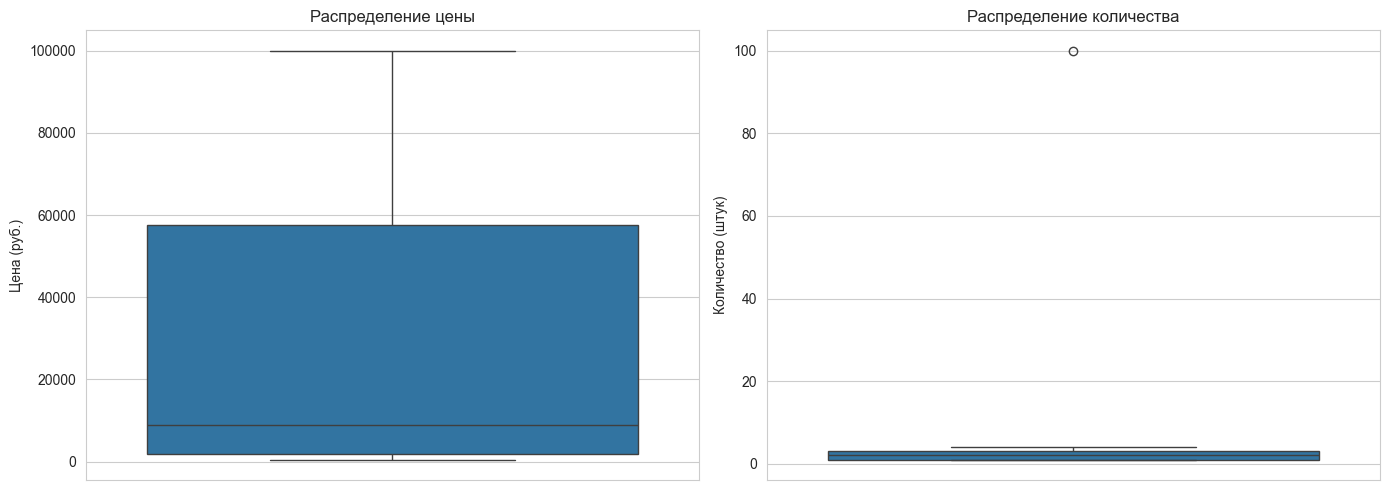

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, y='цена', ax=axes[0])
axes[0].set_title('Распределение цены')
axes[0].set_ylabel('Цена (руб.)')

sns.boxplot(data=df, y='количество', ax=axes[1])
axes[1].set_title('Распределение количества')
axes[1].set_ylabel('Количество (штук)')

plt.tight_layout()
plt.show()

**Вывод по boxplot:**  
- **По цене:** 50% товаров стоят от 10 000 до 60 000 руб. Выбросов по методу IQR нет (максимальная цена 99 971 руб. ниже верхней границы 140 733 руб.).  
- **По количеству:** 50% покупок — 1-2 штуки. Выброс (100 штук) — это аномалия, требующая проверки (возможно, оптовая покупка или ошибка).

### 3.4. Гистограмма цены

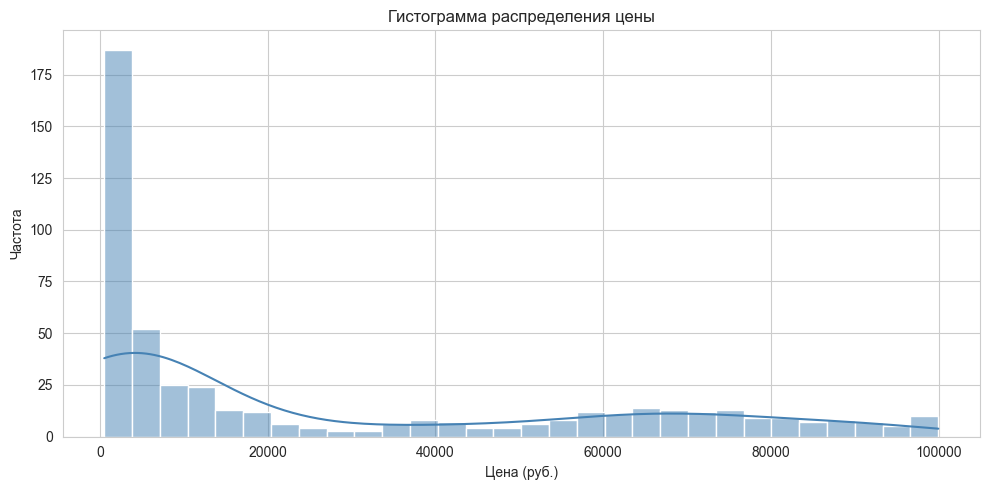

In [69]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='цена', bins=30, kde=True, color='steelblue')
plt.title('Гистограмма распределения цены')
plt.xlabel('Цена (руб.)')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

**Вывод по гистограмме:**  
- Основной диапазон цен: 10 000 – 60 000 руб.  
- Пик продаж: 20 000 – 30 000 руб.  
- Дорогих товаров (выше 90 000 руб.) мало.  
- Распределение скошено вправо — есть длинный правый хвост из дорогих товаров.

## 4. Разведочный анализ (EDA)

### 4.1. Популярность товаров

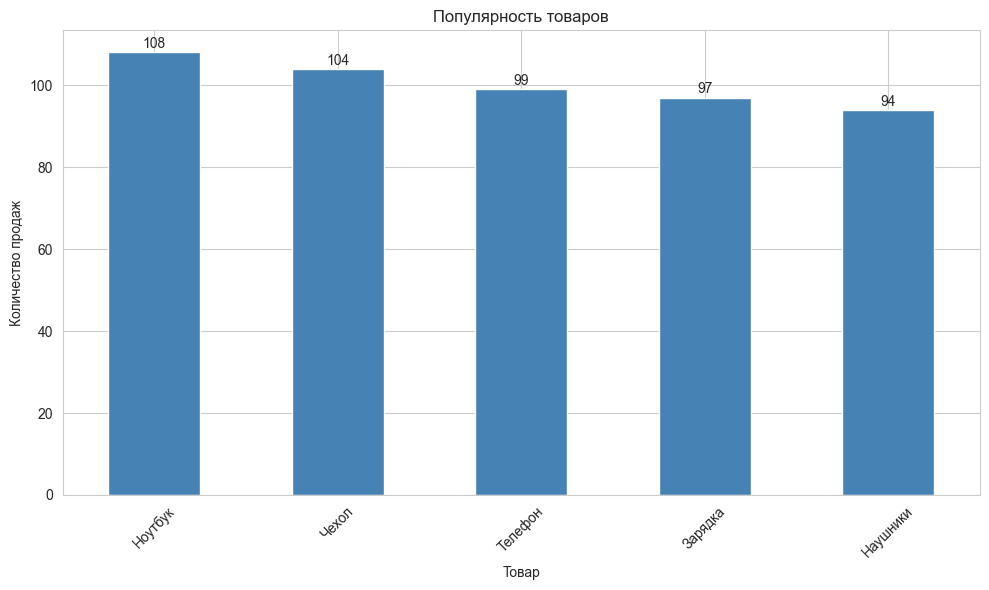

In [70]:
plt.figure(figsize=(10, 6))
product_counts = df['товар'].value_counts()
product_counts.plot(kind='bar', color='steelblue')
plt.title('Популярность товаров')
plt.xlabel('Товар')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)
for i, v in enumerate(product_counts.values):
    plt.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.show()

**Вывод:**  
Продажи распределены между категориями товаров относительно равномерно. Ноутбуки лидируют (108 продаж), наушники на последнем месте (94 продажи). Разница между самым популярным и самым непопулярным товаром — всего 14 продаж.

### 4.2. Продажи по городам

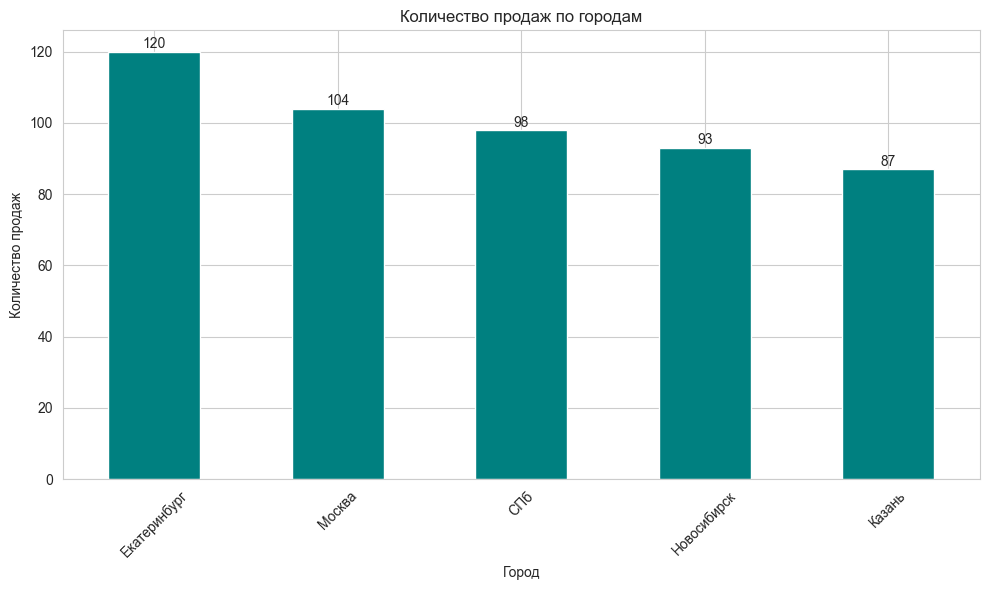

In [71]:
plt.figure(figsize=(10, 6))
city_counts = df['город'].value_counts()
city_counts.plot(kind='bar', color='teal')
plt.title('Количество продаж по городам')
plt.xlabel('Город')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)
for i, v in enumerate(city_counts.values):
    plt.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.show()

**Вывод:**  
Лидеры по продажам — Екатеринбург (120), Москва (104) и Санкт-Петербург (98). Это крупные города с высокой численностью населения и платёжеспособностью.

### 4.3. Способы оплаты

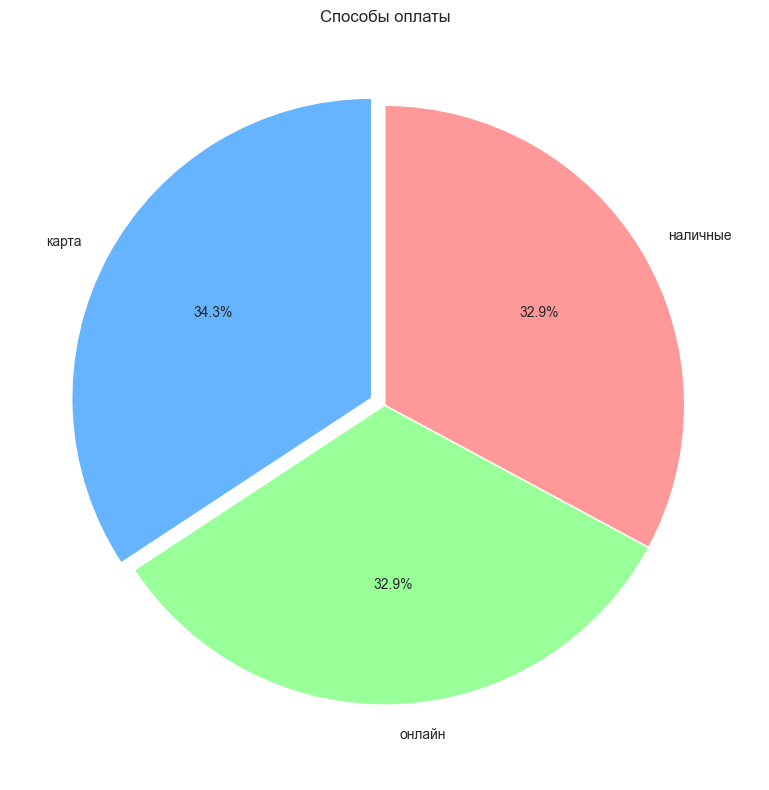

In [72]:
plt.figure(figsize=(8, 8))
payment_counts = df['оплата'].value_counts()
colors = ['#66b3ff', '#99ff99', '#ff9999']
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, explode=(0.05, 0, 0))
plt.title('Способы оплаты')
plt.tight_layout()
plt.show()

**Вывод:**  
Способы оплаты распределены почти поровну: карта (34.6%), онлайн (33.2%), наличные (32.2%). Это говорит об отсутствии барьеров для покупателей — каждый может выбрать удобный способ.

### 4.4. Средняя цена по товарам

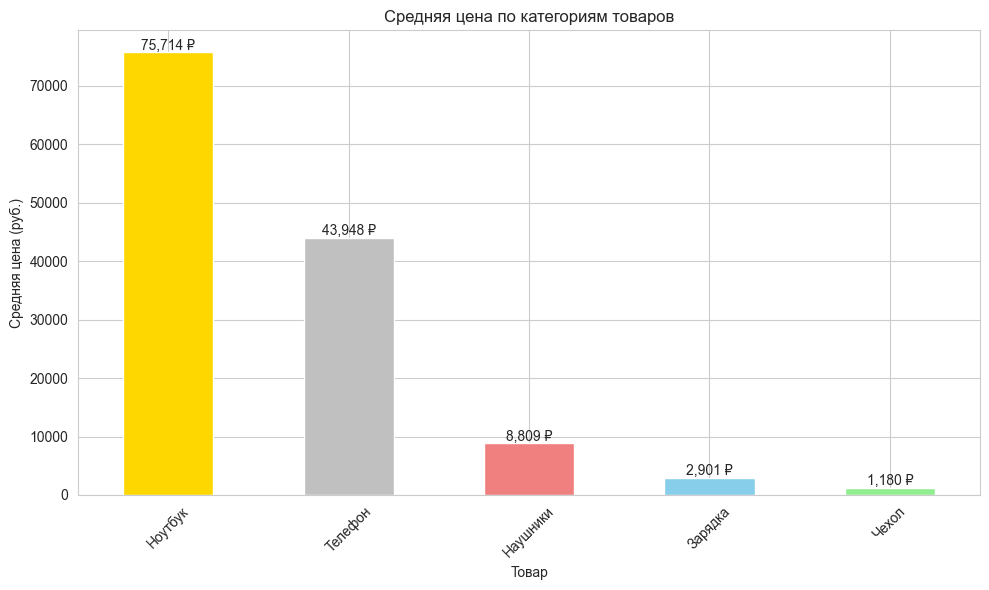

In [73]:
avg_price = df.groupby('товар')['цена'].mean().sort_values(ascending=False).round(0).astype(int)
plt.figure(figsize=(10, 6))
avg_price.plot(kind='bar', color=['gold', 'silver', 'lightcoral', 'skyblue', 'lightgreen'])
plt.title('Средняя цена по категориям товаров')
plt.xlabel('Товар')
plt.ylabel('Средняя цена (руб.)')
plt.xticks(rotation=45)
for i, v in enumerate(avg_price.values):
    plt.text(i, v + 500, f'{v:,} ₽', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

**Вывод:**  
Чёткое разделение на три ценовых сегмента:  
- **Премиум:** ноутбуки (~75 700 ₽) и телефоны (~43 900 ₽)  
- **Средний:** наушники (~8 800 ₽)  
- **Бюджетный:** зарядки (~2 900 ₽) и чехлы (~1 200 ₽)

### 4.5. Связь цены и скидки

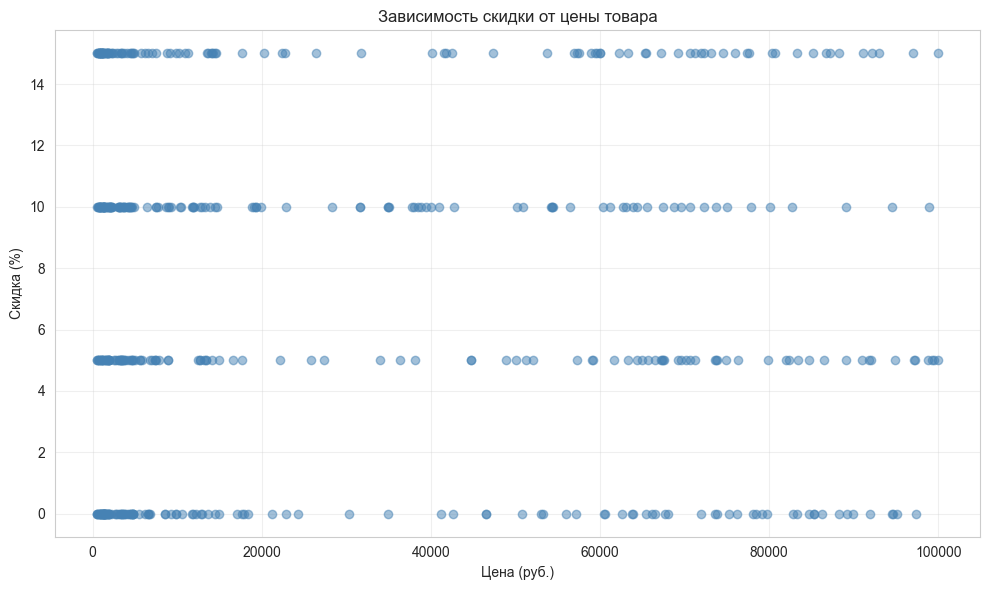

In [74]:
plt.figure(figsize=(10, 6))
df_clean = df.dropna(subset=['скидка_%'])
plt.scatter(df_clean['цена'], df_clean['скидка_%'], alpha=0.5, c='steelblue')
plt.title('Зависимость скидки от цены товара')
plt.xlabel('Цена (руб.)')
plt.ylabel('Скидка (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:**  
Скидки (0-15%) равномерно распределены при любых ценах — от 500 до 100 000 рублей. Чёткой зависимости «дороже товар — больше скидка» не наблюдается. Скидки, вероятно, зависят от маркетинговых акций, а не от цены товара.

## 5. Итоговые выводы

**Основные проблемы качества данных:**

| № | Проблема | Где | Риск | Решение |
|---|----------|-----|------|---------|
| 1 | Пропуски | возраст (11 шт., 2.19%) | Искажение статистики | Заполнить медианой |
| 2 | Пропуски | скидка_% (11 шт., 2.19%) | Небольшой | Заполнить 0 |
| 3 | Ошибка | возраст = 150 лет | Неверный анализ | Удалить строку |
| 4 | Выброс | количество = 100 шт. | Искажает среднее | Проверить (возможно опт) |
| 5 | Дубликаты | по id (2 шт.) | Двойной учёт | Удалить дубликаты |

**План улучшения:**
1. Удалить строку с возрастом 150 лет
2. Удалить дубликаты по id
3. Заполнить пропуски в возрасте медианой
4. Заполнить пропуски в скидке нулём
5. Исследовать выброс 100 штук

**Детальный отчёт:** `report/quality_report.md`